<a href="https://colab.research.google.com/github/liuwan95/AI_security_UHM/blob/main/Empirist_Neural_Cleanse_Identifying_and_Mitigating_Backdoor_Attacks_in_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Cleanse: Identifying a Backdoor Attack in a Neural Network

## Overview

This notebook demonstrates the Neural Cleanse approach for identifying a backdoor in a trained image-classification model. The experiment uses a GTSRB traffic-sign classifier containing a known backdoor associated with target class 33.

The goal of this notebook is not only to demonstrate that the known trigger works, but also to determine whether the compromised target class can be identified without assuming beforehand which class contains the backdoor.

The experiment is divided into four main stages:

1. Load and verify the GTSRB model and dataset.
2. Confirm the behavior of the original backdoor trigger.
3. Recover a trigger for target class 33 using optimization.
4. Perform trigger inversion across all 43 classes and use an anomaly index to identify suspicious classes.

The final experiment compares the recovered mask sizes across all classes. An unusually small mask suggests that the model may have learned a compact backdoor trigger for that target.

In [3]:
!git clone https://github.com/bolunwang/backdoor.git

Cloning into 'backdoor'...
remote: Enumerating objects: 90, done.
remote: Total 90 (delta 0), reused 0 (delta 0), pack-reused 90 (from 1)
Receiving objects: 100% (90/90), 31.93 MiB | 30.36 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [4]:
%cd backdoor

/content/backdoor


In [5]:
!ls

data			    mad_outlier_detection.py  utils_backdoor.py
gtsrb_visualize_example.py  models		      visualizer.py
injection		    README.md
LICENSE			    triggers


In [6]:
!ls -lh models/
!ls -lh data/
!ls -lh triggers/

total 6.6M
-rw-r--r-- 1 root root 6.6M Oct  6 02:07 gtsrb_bottom_right_white_4_target_33.h5
total 38M
-rw-r--r-- 1 root root 38M Oct  6 02:07 gtsrb_dataset_int.h5
total 276K
-rw-r--r-- 1 root root  131 Oct  6 02:07 gtsrb_mask.png
-rw-r--r-- 1 root root 2.9K Oct  6 02:07 gtsrb_pattern.png
-rw-r--r-- 1 root root  990 Oct  6 02:07 vggface_square_mask.png
-rw-r--r-- 1 root root 132K Oct  6 02:07 vggface_square_pattern.png
-rw-r--r-- 1 root root 1.2K Oct  6 02:07 vggface_watermark_mask.png
-rw-r--r-- 1 root root 127K Oct  6 02:07 vggface_watermark_pattern.png


In [7]:
import sys
import platform

print("Python:", sys.version)
print("Architecture:", platform.machine())

try:
    import tensorflow as tf
    print("Tensorflow:", tf.__version__)
except ImportError:
    print("Tensorflow not installed")

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
Architecture: x86_64
Tensorflow: 2.21.0


In [8]:
from pathlib import Path

for folder in["models", "data","triggers"]:
  print(f"\n--- {folder.upper()} ---")

  for file in Path(folder).rglob("*"):
    if file.is_file():
      print(
          file,
          f"({file.stat().st_size / 1024**2: .2f} MB)"
      )


--- MODELS ---
models/gtsrb_bottom_right_white_4_target_33.h5 ( 6.60 MB)

--- DATA ---
data/gtsrb_dataset_int.h5 ( 37.52 MB)

--- TRIGGERS ---
triggers/vggface_square_mask.png ( 0.00 MB)
triggers/vggface_watermark_mask.png ( 0.00 MB)
triggers/vggface_square_pattern.png ( 0.13 MB)
triggers/vggface_watermark_pattern.png ( 0.12 MB)
triggers/gtsrb_mask.png ( 0.00 MB)
triggers/gtsrb_pattern.png ( 0.00 MB)


In [9]:
from pathlib import Path

script = Path("gtsrb_visualize_example.py")

print(script.read_text()[:12000])

#!/usr/bin/env python
# -*- coding: utf-8 -*-
# @Date    : 2018-11-05 11:30:01
# @Author  : Bolun Wang (bolunwang@cs.ucsb.edu)
# @Link    : http://cs.ucsb.edu/~bolunwang

import os
import time

import numpy as np
import random
from tensorflow import set_random_seed
random.seed(123)
np.random.seed(123)
set_random_seed(123)

from keras.models import load_model
from keras.preprocessing.image import ImageDataGenerator

from visualizer import Visualizer

import utils_backdoor


##############################
#        PARAMETERS          #
##############################

DEVICE = '3'  # specify which GPU to use

DATA_DIR = 'data'  # data folder
DATA_FILE = 'gtsrb_dataset_int.h5'  # dataset file
MODEL_DIR = 'models'  # model directory
MODEL_FILENAME = 'gtsrb_bottom_right_white_4_target_33.h5'  # model file
RESULT_DIR = 'results'  # directory for storing results
# image filename template for visualization results
IMG_FILENAME_TEMPLATE = 'gtsrb_visualize_%s_label_%d.png'

# input size
IMG_ROWS 

In [10]:
%cd /content
!git clone https://github.com/bolunwang/backdoor.git
%cd /content/backdoor
!ls

/content
fatal: destination path 'backdoor' already exists and is not an empty directory.
/content/backdoor
data			    mad_outlier_detection.py  utils_backdoor.py
gtsrb_visualize_example.py  models		      visualizer.py
injection		    README.md
LICENSE			    triggers


In [11]:
from pathlib import Path

root = Path("/content/backdoor")

for folder in ["models", "data", "triggers"]:
    print(f"\n=== {folder.upper()} ===")

    for path in sorted((root / folder).rglob("*")):
        if path.is_file():
            size = path.stat().st_size / (1024 * 1024)
            print(f"{path.relative_to(root)} — {size:.2f} MB")


=== MODELS ===
models/gtsrb_bottom_right_white_4_target_33.h5 — 6.60 MB

=== DATA ===
data/gtsrb_dataset_int.h5 — 37.52 MB

=== TRIGGERS ===
triggers/gtsrb_mask.png — 0.00 MB
triggers/gtsrb_pattern.png — 0.00 MB
triggers/vggface_square_mask.png — 0.00 MB
triggers/vggface_square_pattern.png — 0.13 MB
triggers/vggface_watermark_mask.png — 0.00 MB
triggers/vggface_watermark_pattern.png — 0.12 MB


In [12]:
from pathlib import Path

script = Path("/content/backdoor/gtsrb_visualize_example.py")

for number, line in enumerate(script.read_text().splitlines(), start=1):
    print(f"{number:3}: {line}")

  1: #!/usr/bin/env python
  2: # -*- coding: utf-8 -*-
  3: # @Date    : 2018-11-05 11:30:01
  4: # @Author  : Bolun Wang (bolunwang@cs.ucsb.edu)
  5: # @Link    : http://cs.ucsb.edu/~bolunwang
  6: 
  7: import os
  8: import time
  9: 
 10: import numpy as np
 11: import random
 12: from tensorflow import set_random_seed
 13: random.seed(123)
 14: np.random.seed(123)
 15: set_random_seed(123)
 16: 
 17: from keras.models import load_model
 18: from keras.preprocessing.image import ImageDataGenerator
 19: 
 20: from visualizer import Visualizer
 21: 
 22: import utils_backdoor
 23: 
 24: 
 25: ##############################
 26: #        PARAMETERS          #
 27: ##############################
 28: 
 29: DEVICE = '3'  # specify which GPU to use
 30: 
 31: DATA_DIR = 'data'  # data folder
 32: DATA_FILE = 'gtsrb_dataset_int.h5'  # dataset file
 33: MODEL_DIR = 'models'  # model directory
 34: MODEL_FILENAME = 'gtsrb_bottom_right_white_4_target_33.h5'  # model file
 35: RESULT_DIR = '

In [13]:
import sys
import importlib.metadata as metadata

print("Python:", sys.version.split()[0])

for package in ["tensorflow", "keras", "numpy", "h5py"]:
    try:
        print(f"{package}: {metadata.version(package)}")
    except metadata.PackageNotFoundError:
        print(f"{package}: not installed")

Python: 3.13.16
tensorflow: 2.21.0
keras: 3.13.2
numpy: 2.1.3
h5py: 3.14.0


In [14]:
import h5py

model_path = (
    "/content/backdoor/models/"
    "gtsrb_bottom_right_white_4_target_33.h5"
)

with h5py.File(model_path, "r") as f:
    print("=== MODEL FILE ===")
    print("Top-level keys:", list(f.keys()))

    print("\n=== FILE ATTRIBUTES ===")
    for key, value in f.attrs.items():
        if key == "model_config":
            print("model_config: PRESENT")
        else:
            print(f"{key}: {str(value)[:200]}")

    print("\n=== WEIGHTS ===")
    if "model_weights" in f:
        print("Model weights: PRESENT")
        print(
            "Layer groups:",
            list(f["model_weights"].keys())[:15]
        )
    else:
        print("Model weights: NOT FOUND")

=== MODEL FILE ===
Top-level keys: ['model_weights', 'optimizer_weights']

=== FILE ATTRIBUTES ===
backend: tensorflow
keras_version: 2.1.2
model_config: PRESENT
training_config: {"metrics": ["accuracy"], "loss": "categorical_crossentropy", "optimizer_config": {"class_name": "Adadelta", "config": {"epsilon": 1e-08, "lr": 1.0, "rho": 0.95, "decay": 0.0}}, "loss_weights": null, 

=== WEIGHTS ===
Model weights: PRESENT
Layer groups: ['activation_1', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4', 'conv2d_5', 'conv2d_6', 'dense_1', 'dense_2', 'flatten_1', 'max_pooling2d_1', 'max_pooling2d_2', 'max_pooling2d_3']


In [15]:
import tensorflow as tf

model_path = (
    "/content/backdoor/models/"
    "gtsrb_bottom_right_white_4_target_33.h5"
)

print("TensorFlow:", tf.__version__)

try:
    model = tf.keras.models.load_model(
        model_path,
        compile=False
    )

    print("\nMODEL LOADED SUCCESSFULLY")
    print("Input shape:", model.input_shape)
    print("Output shape:", model.output_shape)

    model.summary()

except Exception as error:
    print("\nMODEL LOADING FAILED")
    print("Error type:", type(error).__name__)
    print("Error message:", str(error)[:3000])

TensorFlow: 2.21.0

MODEL LOADING FAILED
Error type: TypeError
Error message: pop expected at most 1 argument, got 2


In [16]:
import json
import h5py
import traceback
import tensorflow as tf

model_path = (
    "/content/backdoor/models/"
    "gtsrb_bottom_right_white_4_target_33.h5"
)

with h5py.File(model_path, "r") as f:
    config = json.loads(f.attrs["model_config"])

print("=== MODEL ARCHITECTURE ===")
print("Model type:", config["class_name"])

# Older Sequential models store their layers as a list.
layers = config["config"]

if isinstance(layers, dict):
    layers = layers["layers"]

for layer in layers:
    name = layer["config"].get("name")
    layer_type = layer["class_name"]
    print(f"{name}: {layer_type}")

print("\n=== FULL MODEL LOADING ERROR ===")

try:
    model = tf.keras.models.load_model(
        model_path,
        compile=False
    )
    print("MODEL LOADED SUCCESSFULLY")
    model.summary()

except Exception:
    traceback.print_exc(limit=12)

=== MODEL ARCHITECTURE ===
Model type: Sequential
conv2d_1: Conv2D
conv2d_2: Conv2D
max_pooling2d_1: MaxPooling2D
conv2d_3: Conv2D
conv2d_4: Conv2D
max_pooling2d_2: MaxPooling2D
conv2d_5: Conv2D
conv2d_6: Conv2D
max_pooling2d_3: MaxPooling2D
flatten_1: Flatten
dense_1: Dense
dense_2: Dense
activation_1: Activation

=== FULL MODEL LOADING ERROR ===


Traceback (most recent call last):
  File "/tmp/ipykernel_1039/4012425282.py", line 31, in <cell line: 0>
    model = tf.keras.models.load_model(
        model_path,
        compile=False
    )
  File "/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_api.py", line 196, in load_model
    return legacy_h5_format.load_model_from_hdf5(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        filepath,
        ^^^^^^^^^
    ...<2 lines>...
        safe_mode=safe_mode,
        ^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/keras/src/legacy/saving/legacy_h5_format.py", line 137, in load_model_from_hdf5
    model = saving_utils.model_from_config(
        model_config, custom_objects=custom_objects
    )
  File "/usr/local/lib/python3.13/dist-packages/keras/src/legacy/saving/saving_utils.py", line 57, in model_from_config
    batch_input_shape = config["config"].pop("batch_input_shape", None)
TypeError: pop expected at most 1 argument, got 2


In [17]:
import json
import h5py
import tensorflow as tf

model_path = (
    "/content/backdoor/models/"
    "gtsrb_bottom_right_white_4_target_33.h5"
)

# Read the original model configuration.
with h5py.File(model_path, "r") as f:
    config = json.loads(f.attrs["model_config"])

# Adapt the old Sequential configuration to the format
# expected by the modern Keras deserializer.
if isinstance(config["config"], list):
    config["config"] = {
        "name": "sequential",
        "layers": config["config"]
    }

try:
    model = tf.keras.models.model_from_json(
        json.dumps(config)
    )

    print("ARCHITECTURE RECONSTRUCTED")
    print("Input shape:", model.input_shape)
    print("Output shape:", model.output_shape)

    model.summary()

except Exception as error:
    print("RECONSTRUCTION FAILED")
    print(type(error).__name__)
    print(str(error)[:3000])

RECONSTRUCTION FAILED
TypeError
Could not locate class 'Sequential'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'class_name': 'Sequential', 'config': {'name': 'sequential', 'layers': [{'class_name': 'Conv2D', 'config': {'kernel_initializer': {'class_name': 'VarianceScaling', 'config': {'distribution': 'uniform', 'scale': 1.0, 'seed': None, 'mode': 'fan_avg'}}, 'name': 'conv2d_1', 'kernel_constraint': None, 'bias_regularizer': None, 'bias_constraint': None, 'dtype': 'float32', 'activation': 'relu', 'trainable': True, 'data_format': 'channels_last', 'filters': 32, 'padding': 'same', 'strides': [1, 1], 'dilation_rate': [1, 1], 'kernel_regularizer': None, 'bias_initializer': {'class_name': 'Zeros', 'config': {}}, 'batch_input_shape': [None, 32, 32, 3], 'use_bias': True, 'activity_regularize

## 1. Model and Dataset Verification

- Load the GTSRB dataset and reconstruct the provided model.
- The model takes `32 × 32 × 3` images and predicts across 43 traffic-sign classes.
- Test clean images first to establish how the model behaves without a trigger.

In [18]:
import json
import h5py
import tensorflow as tf

model_path = (
    "/content/backdoor/models/"
    "gtsrb_bottom_right_white_4_target_33.h5"
)

with h5py.File(model_path, "r") as f:
    config = json.loads(f.attrs["model_config"])

layers = config["config"]

if isinstance(layers, dict):
    layers = layers["layers"]

# Create a modern container for the original architecture.
model = tf.keras.Sequential(name="original_gtsrb")

model.add(tf.keras.Input(shape=(32, 32, 3)))

for layer in layers:
    layer_type = layer["class_name"]
    layer_config = dict(layer["config"])

    # This legacy setting is replaced by the Input layer above.
    layer_config.pop("batch_input_shape", None)

    layer_class = getattr(tf.keras.layers, layer_type)

    # Reconstruct each original layer.
    new_layer = layer_class.from_config(layer_config)
    model.add(new_layer)

print("ARCHITECTURE RECONSTRUCTED")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

model.summary()

ARCHITECTURE RECONSTRUCTED
Input shape: (None, 32, 32, 3)
Output shape: (None, 43)


Model: "original_gtsrb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 43)             │        22,059 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 43)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,723 (2.18 MB)

 Trainable params: 571,723 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import h5py
import numpy as np

model_path = (
    "/content/backdoor/models/"
    "gtsrb_bottom_right_white_4_target_33.h5"
)

loaded_layers = []

with h5py.File(model_path, "r") as f:
    weight_group = f["model_weights"]

    for layer in model.layers:
        if not layer.weights:
            continue

        group = weight_group[layer.name]

        # Original Keras HDF5 files may nest weights
        # inside a second group named after the layer.
        if layer.name in group:
            group = group[layer.name]

        original_weights = []

        for weight_name in ["kernel:0", "bias:0"]:
            if weight_name in group:
                original_weights.append(
                    np.array(group[weight_name])
                )

        expected = layer.get_weights()

        if len(original_weights) != len(expected):
            raise ValueError(
                f"{layer.name}: expected {len(expected)} "
                f"weight arrays, found {len(original_weights)}"
            )

        for saved, current in zip(original_weights, expected):
            if saved.shape != current.shape:
                raise ValueError(
                    f"{layer.name}: saved shape {saved.shape}, "
                    f"expected {current.shape}"
                )

        layer.set_weights(original_weights)
        loaded_layers.append(layer.name)
        print(f"Loaded: {layer.name}")

print("\nWEIGHT RESTORATION COMPLETE")
print("Layers restored:", len(loaded_layers))
print("Total parameters:", model.count_params())

Loaded: conv2d_1
Loaded: conv2d_2
Loaded: conv2d_3
Loaded: conv2d_4
Loaded: conv2d_5
Loaded: conv2d_6
Loaded: dense_1
Loaded: dense_2

WEIGHT RESTORATION COMPLETE
Layers restored: 8
Total parameters: 571723


In [20]:
import h5py
import numpy as np

data_path = "/content/backdoor/data/gtsrb_dataset_int.h5"

with h5py.File(data_path, "r") as f:
    print("=== DATASET CONTENTS ===")
    for key in f.keys():
        print(key, f[key].shape, f[key].dtype)

    X_test = np.array(f["X_test"], dtype=np.float32)
    Y_test = np.array(f["Y_test"])

print("\n=== TEST DATA ===")
print("Image shape:", X_test.shape)
print("Label shape:", Y_test.shape)
print("Pixel range:", X_test.min(), "to", X_test.max())

print("\n=== FIRST IMAGE ===")
print("First label:", Y_test[0])
print("Image shape:", X_test[0].shape)

=== DATASET CONTENTS ===
X_test (12630, 32, 32, 3) uint8
Y_test (12630, 43) uint8

=== TEST DATA ===
Image shape: (12630, 32, 32, 3)
Label shape: (12630, 43)
Pixel range: 0.0 to 255.0

=== FIRST IMAGE ===
First label: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]
Image shape: (32, 32, 3)


In [21]:
import numpy as np

# Use the first 100 original test images.
X_sample = X_test[:100]
Y_sample = Y_test[:100]

# Obtain the model's predictions.
predictions = model.predict(
    X_sample,
    batch_size=32,
    verbose=0
)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(Y_sample, axis=1)

accuracy = np.mean(predicted_labels == true_labels)

print("=== CLEAN MODEL TEST ===")
print("Images tested:", len(X_sample))
print(f"Accuracy: {accuracy * 100:.1f}%")

print("\nFirst 10 predictions:")
for i in range(10):
    print(
        f"Image {i}: "
        f"Actual={true_labels[i]}, "
        f"Predicted={predicted_labels[i]}"
    )

=== CLEAN MODEL TEST ===
Images tested: 100
Accuracy: 99.0%

First 10 predictions:
Image 0: Actual=0, Predicted=0
Image 1: Actual=0, Predicted=0
Image 2: Actual=0, Predicted=0
Image 3: Actual=0, Predicted=0
Image 4: Actual=0, Predicted=0
Image 5: Actual=0, Predicted=0
Image 6: Actual=0, Predicted=0
Image 7: Actual=0, Predicted=0
Image 8: Actual=0, Predicted=0
Image 9: Actual=0, Predicted=0


In [22]:
import numpy as np

TARGET = 33
rng = np.random.default_rng(123)

true_labels = np.argmax(Y_test, axis=1)

selected_indices = []

for label in range(43):
    if label == TARGET:
        continue

    candidates = np.where(true_labels == label)[0]

    chosen = rng.choice(
        candidates,
        size=min(5, len(candidates)),
        replace=False
    )

    selected_indices.extend(chosen)

selected_indices = np.array(selected_indices)

X_sample = X_test[selected_indices].copy()
Y_sample = true_labels[selected_indices]

print("Images selected:", len(X_sample))
print("Classes represented:", len(np.unique(Y_sample)))
print("Target-class images included:", np.sum(Y_sample == TARGET))

clean_predictions = model.predict(
    X_sample,
    batch_size=32,
    verbose=0
)

clean_labels = np.argmax(clean_predictions, axis=1)

print(
    "Clean accuracy:",
    f"{np.mean(clean_labels == Y_sample) * 100:.1f}%"
)

print(
    "Clean images predicted as label 33:",
    np.sum(clean_labels == TARGET)
)

Images selected: 210
Classes represented: 42
Target-class images included: 0
Clean accuracy: 94.8%
Clean images predicted as label 33: 0


=== ORIGINAL BACKDOOR EXPERIMENT ===
Images: 210
Clean accuracy: 94.8%
Attack success rate: 97.6%
Attack success on originally correct images: 97.5%


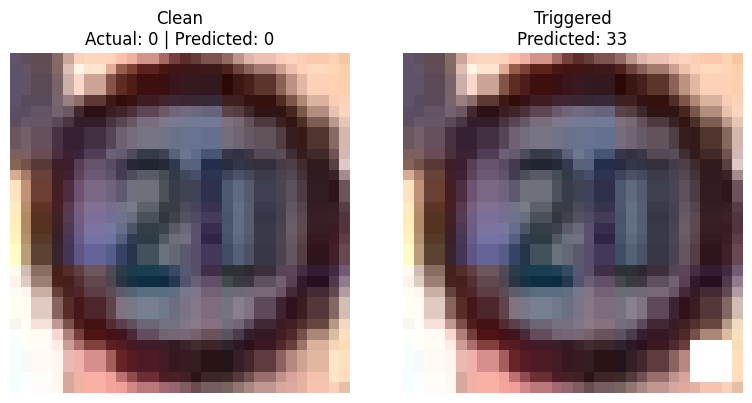

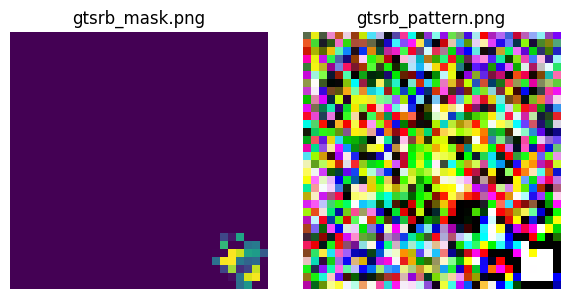

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

ROOT = Path("/content/backdoor")
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

TARGET = 33

# Use the same 210 images from your previous experiment.
# Make sure X_sample and Y_sample still exist.
assert X_sample.shape == (210, 32, 32, 3)
assert not np.any(Y_sample == TARGET)

# Create triggered copies without modifying the clean originals.
X_triggered = X_sample.copy()
X_triggered[:, 27:31, 27:31, :] = 255.0

# Evaluate both versions.
clean_probs = model.predict(
    X_sample, batch_size=32, verbose=0
)
triggered_probs = model.predict(
    X_triggered, batch_size=32, verbose=0
)

clean_pred = np.argmax(clean_probs, axis=1)
triggered_pred = np.argmax(triggered_probs, axis=1)

clean_accuracy = np.mean(clean_pred == Y_sample)
attack_success = np.mean(triggered_pred == TARGET)

# A stricter measure: only images classified correctly when clean.
clean_correct = clean_pred == Y_sample

attack_success_on_clean_correct = np.mean(
    triggered_pred[clean_correct] == TARGET
)

print("=== ORIGINAL BACKDOOR EXPERIMENT ===")
print(f"Images: {len(X_sample)}")
print(f"Clean accuracy: {clean_accuracy:.1%}")
print(f"Attack success rate: {attack_success:.1%}")
print(
    "Attack success on originally correct images:",
    f"{attack_success_on_clean_correct:.1%}"
)

# Display one example that the trigger successfully redirects,
# if such an example exists.
successful = np.where(
    (clean_pred == Y_sample) &
    (triggered_pred == TARGET)
)[0]

if len(successful):
    idx = successful[0]
else:
    idx = 0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(X_sample[idx].astype(np.uint8))
axes[0].set_title(
    f"Clean\nActual: {Y_sample[idx]} | "
    f"Predicted: {clean_pred[idx]}"
)

axes[1].imshow(X_triggered[idx].astype(np.uint8))
axes[1].set_title(
    f"Triggered\nPredicted: {triggered_pred[idx]}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    RESULTS / "clean_vs_triggered.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

# Inspect the researchers' supplied trigger assets.
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, filename in zip(
    axes,
    ["gtsrb_mask.png", "gtsrb_pattern.png"]
):
    image = Image.open(ROOT / "triggers" / filename)
    ax.imshow(image)
    ax.set_title(filename)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Model and Backdoor Verification

Before working with Neural Cleanse, I first test how the reconstructed model behaves on clean images and then compare this against its behavior when the known backdoor trigger is applied.

- The model is tested on clean GTSRB images to establish a baseline.
- The main evaluation set contains **210 images** from the non-target classes.
- Class **33** is excluded because it is the known target of the provided backdoor.
- The model achieved **94.8% clean accuracy** on this evaluation set.
- After applying the known trigger, the attack success rate (ASR) toward class 33 was **97.6%**.

These results give me a baseline for comparing the original backdoor behavior with the trigger that I later attempt to recover using Neural Cleanse.

In [24]:
import tensorflow as tf
import time

tf.random.set_seed(123)
np.random.seed(123)

model.trainable = False

# Select different images from those used in our demonstration.
all_labels = np.argmax(Y_test, axis=1)
used_indices = set(selected_indices.tolist())

recovery_indices = []

rng = np.random.default_rng(456)

for label in range(43):
    if label == TARGET:
        continue

    candidates = [
        i for i in np.where(all_labels == label)[0]
        if i not in used_indices
    ]

    chosen = rng.choice(
        candidates,
        size=min(5, len(candidates)),
        replace=False
    )

    recovery_indices.extend(chosen)

X_recovery = X_test[recovery_indices].astype(np.float32)

print("Recovery images:", len(X_recovery))

# These are the ONLY trainable variables.
# The original model weights remain frozen.
pattern_var = tf.Variable(
    tf.random.uniform((1, 32, 32, 3), -0.1, 0.1)
)

mask_var = tf.Variable(
    tf.random.uniform((1, 32, 32, 1), -0.1, 0.1)
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.1,
    beta_1=0.5,
    beta_2=0.9
)

STEPS = 300
BATCH_SIZE = 32
cost = 0.001

best_norm = float("inf")
best_pattern = None
best_mask = None

history = []
start_time = time.time()

for step in range(STEPS):

    batch_indices = rng.choice(
        len(X_recovery),
        size=BATCH_SIZE,
        replace=False
    )

    batch = tf.constant(X_recovery[batch_indices])

    with tf.GradientTape() as tape:

        # Keep mask between 0 and 1.
        mask = (tf.tanh(mask_var) + 1.0) / 2.0

        # Keep pattern between 0 and 255.
        pattern = (
            (tf.tanh(pattern_var) + 1.0) / 2.0
        ) * 255.0

        # Blend candidate trigger into clean images.
        modified = (
            (1.0 - mask) * batch +
            mask * pattern
        )

        predictions = model(modified, training=False)

        target_labels = tf.fill(
            [BATCH_SIZE], TARGET
        )

        classification_loss = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(
                target_labels,
                predictions
            )
        )

        mask_norm = tf.reduce_sum(mask)

        loss = (
            classification_loss +
            cost * mask_norm
        )

    gradients = tape.gradient(
        loss,
        [pattern_var, mask_var]
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            [pattern_var, mask_var]
        )
    )

    success = np.mean(
        np.argmax(predictions.numpy(), axis=1)
        == TARGET
    )

    current_norm = float(mask_norm.numpy())

    history.append({
        "step": step + 1,
        "success": float(success),
        "mask_norm": current_norm,
        "loss": float(loss.numpy()),
        "cost": cost
    })

    # Preserve the smallest successful mask observed.
    if success >= 0.95 and current_norm < best_norm:
        best_norm = current_norm
        best_pattern = pattern.numpy()[0].copy()
        best_mask = mask.numpy()[0, :, :, 0].copy()

    # Simplified adaptive mask penalty.
    if (step + 1) % 20 == 0:
        if success >= 0.95:
            cost *= 1.5
        else:
            cost /= 1.5

    if (step + 1) % 25 == 0:
        print(
            f"Step {step + 1:3d}/{STEPS} | "
            f"Success: {success:.1%} | "
            f"Mask norm: {current_norm:.2f} | "
            f"Cost: {cost:.6f}"
        )

# If the threshold was never reached, retain the final candidate.
if best_pattern is None:
    print(
        "WARNING: No candidate met the 95% "
        "mini-batch success threshold."
    )

    best_pattern = (
        (tf.tanh(pattern_var) + 1.0) / 2.0
        * 255.0
    ).numpy()[0]

    best_mask = (
        (tf.tanh(mask_var) + 1.0) / 2.0
    ).numpy()[0, :, :, 0]

    best_norm = float(np.sum(best_mask))

elapsed = time.time() - start_time

print("\n=== RECOVERY COMPLETE ===")
print(f"Execution time: {elapsed:.1f} seconds")
print(f"Recovered mask L1 norm: {best_norm:.2f}")

Recovery images: 210
Step  25/300 | Success: 100.0% | Mask norm: 480.18 | Cost: 0.001500
Step  50/300 | Success: 100.0% | Mask norm: 303.02 | Cost: 0.002250
Step  75/300 | Success: 100.0% | Mask norm: 147.88 | Cost: 0.003375
Step 100/300 | Success: 100.0% | Mask norm: 58.17 | Cost: 0.007594
Step 125/300 | Success: 100.0% | Mask norm: 33.31 | Cost: 0.011391
Step 150/300 | Success: 100.0% | Mask norm: 19.04 | Cost: 0.017086
Step 175/300 | Success: 100.0% | Mask norm: 15.28 | Cost: 0.025629
Step 200/300 | Success: 100.0% | Mask norm: 14.65 | Cost: 0.057665
Step 225/300 | Success: 100.0% | Mask norm: 13.98 | Cost: 0.086498
Step 250/300 | Success: 100.0% | Mask norm: 13.02 | Cost: 0.129746
Step 275/300 | Success: 100.0% | Mask norm: 12.13 | Cost: 0.194620
Step 300/300 | Success: 100.0% | Mask norm: 11.55 | Cost: 0.437894

=== RECOVERY COMPLETE ===
Execution time: 62.5 seconds
Recovered mask L1 norm: 10.99


##Neural Cleanse Trigger Recovery
The next step is to work through the trigger-inversion idea used by Neural Cleanse. Instead of using the original trigger, I try to recover a new mask and pattern that can cause clean images to be classified as a selected target class.

For this first test, I use the known target, class 33, so I can see whether the recovery process can reproduce similar backdoor behavior.

The mask represents where the recovered trigger is being applied.
The pattern represents what is being added to those locations.
The recovered trigger achieved an ASR of 91.4% toward class 33.
The detailed recovery produced a mask L1 norm of 10.99.
This gave me a working example of trigger recovery before expanding the process to all possible target classes.

=== FINAL EXPERIMENT RESULTS ===
Images tested: 210
Clean accuracy: 94.8%
Recovered trigger ASR: 91.4%
Recovered mask L1 norm: 10.99
Recovery time: 62.5 seconds
Original trigger ASR: 97.6%


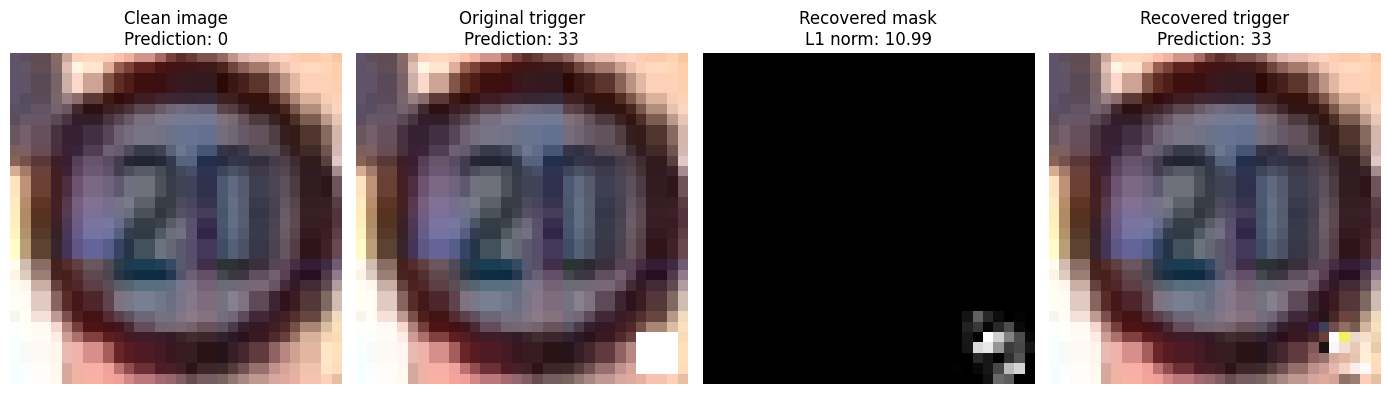


Results and images saved to: /content/backdoor/results


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import json

RESULTS = Path("/content/backdoor/results")
RESULTS.mkdir(exist_ok=True)

TARGET = 33

# Apply the recovered trigger to our held-out test images.
mask_3d = best_mask[:, :, None]

X_recovered = (
    (1.0 - mask_3d) * X_sample
    + mask_3d * best_pattern
).astype(np.float32)

# Test the recovered trigger.
recovered_probs = model.predict(
    X_recovered,
    batch_size=32,
    verbose=0
)

recovered_pred = np.argmax(recovered_probs, axis=1)

recovered_asr = np.mean(recovered_pred == TARGET)

# Recalculate clean accuracy for comparison.
clean_probs = model.predict(
    X_sample,
    batch_size=32,
    verbose=0
)

clean_pred = np.argmax(clean_probs, axis=1)
clean_accuracy = np.mean(clean_pred == Y_sample)

print("=== FINAL EXPERIMENT RESULTS ===")
print(f"Images tested: {len(X_sample)}")
print(f"Clean accuracy: {clean_accuracy:.1%}")
print(f"Recovered trigger ASR: {recovered_asr:.1%}")
print(f"Recovered mask L1 norm: {best_norm:.2f}")
print(f"Recovery time: {elapsed:.1f} seconds")

# If the original-trigger experiment was already run,
# include its attack success rate.
if "attack_success" in globals():
    print(f"Original trigger ASR: {attack_success:.1%}")

# Visualize the recovered mask and its effect.
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

axes[0].imshow(X_sample[0].astype(np.uint8))
axes[0].set_title(
    f"Clean image\nPrediction: {clean_pred[0]}"
)

# Apply the known 4x4 white-square trigger.
original_triggered = X_sample[0].copy()
original_triggered[27:31, 27:31, :] = 255

original_prediction = np.argmax(
    model.predict(
        original_triggered[None, ...],
        verbose=0
    ),
    axis=1
)[0]

axes[1].imshow(original_triggered.astype(np.uint8))
axes[1].set_title(
    f"Original trigger\nPrediction: {original_prediction}"
)

axes[2].imshow(
    best_mask,
    cmap="gray",
    vmin=0,
    vmax=1
)
axes[2].set_title(
    f"Recovered mask\nL1 norm: {best_norm:.2f}"
)

axes[3].imshow(
    np.clip(X_recovered[0], 0, 255).astype(np.uint8)
)
axes[3].set_title(
    f"Recovered trigger\nPrediction: {recovered_pred[0]}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    RESULTS / "final_trigger_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Save the recovered pattern and mask.
Image.fromarray(
    np.clip(best_pattern, 0, 255).astype(np.uint8)
).save(RESULTS / "recovered_pattern.png")

Image.fromarray(
    np.clip(best_mask * 255, 0, 255).astype(np.uint8)
).save(RESULTS / "recovered_mask.png")

print("\nResults and images saved to:", RESULTS)

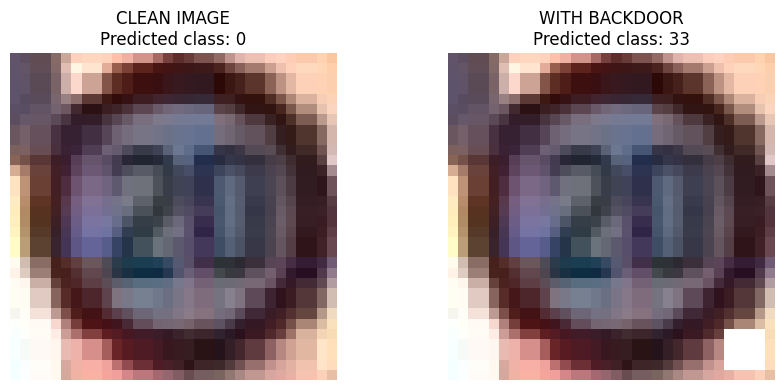

Original class: 0
Clean prediction: 0
Triggered prediction: 33


In [27]:

import numpy as np
import matplotlib.pyplot as plt

# Find an image that is correctly classified when clean
# and redirected to class 33 with the original trigger.
clean_predictions = np.argmax(
    model.predict(X_sample, verbose=0), axis=1
)

triggered_images = X_sample.copy()
triggered_images[:, 27:31, 27:31, :] = 255.0

triggered_predictions = np.argmax(
    model.predict(triggered_images, verbose=0), axis=1
)

successful = np.where(
    (clean_predictions == Y_sample) &
    (triggered_predictions == 33)
)[0]

if len(successful) == 0:
    print("No successful example found in this sample.")
else:
    idx = successful[0]

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].imshow(X_sample[idx].astype(np.uint8))
    axes[0].set_title(
        f"CLEAN IMAGE\nPredicted class: {clean_predictions[idx]}"
    )

    axes[1].imshow(triggered_images[idx].astype(np.uint8))
    axes[1].set_title(
        f"WITH BACKDOOR\nPredicted class: {triggered_predictions[idx]}"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print("Original class:", Y_sample[idx])
    print("Clean prediction:", clean_predictions[idx])
    print("Triggered prediction:", triggered_predictions[idx])


In [28]:
import tensorflow as tf
import numpy as np
import time

model.trainable = False

def recover_trigger_for_target(
    target,
    X_source,
    steps=100,
    batch_size=32,
    seed=1000
):
    tf.random.set_seed(seed + target)
    rng_local = np.random.default_rng(seed + target)

    pattern_var = tf.Variable(
        tf.random.uniform(
            (1, 32, 32, 3),
            -0.1,
            0.1
        )
    )

    mask_var = tf.Variable(
        tf.random.uniform(
            (1, 32, 32, 1),
            -0.1,
            0.1
        )
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.1,
        beta_1=0.5,
        beta_2=0.9
    )

    cost = 0.001

    best_norm = float("inf")
    best_mask_local = None
    best_pattern_local = None
    best_success = 0.0

    for step in range(steps):

        replace = len(X_source) < batch_size

        batch_indices = rng_local.choice(
            len(X_source),
            size=batch_size,
            replace=replace
        )

        batch = tf.constant(
            X_source[batch_indices],
            dtype=tf.float32
        )

        with tf.GradientTape() as tape:

            mask = (
                tf.tanh(mask_var) + 1.0
            ) / 2.0

            pattern = (
                (tf.tanh(pattern_var) + 1.0)
                / 2.0
            ) * 255.0

            modified = (
                (1.0 - mask) * batch
                + mask * pattern
            )

            predictions = model(
                modified,
                training=False
            )

            target_labels = tf.fill(
                [batch_size],
                target
            )

            classification_loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(
                    target_labels,
                    predictions
                )
            )

            mask_norm = tf.reduce_sum(mask)

            loss = (
                classification_loss
                + cost * mask_norm
            )

        gradients = tape.gradient(
            loss,
            [pattern_var, mask_var]
        )

        optimizer.apply_gradients(
            zip(
                gradients,
                [pattern_var, mask_var]
            )
        )

        predictions_np = np.argmax(
            predictions.numpy(),
            axis=1
        )

        success = np.mean(
            predictions_np == target
        )

        current_norm = float(
            mask_norm.numpy()
        )

        if (
            success >= 0.95
            and current_norm < best_norm
        ):
            best_norm = current_norm

            best_mask_local = (
                mask.numpy()[0, :, :, 0].copy()
            )

            best_pattern_local = (
                pattern.numpy()[0].copy()
            )

            best_success = success

        if (step + 1) % 20 == 0:

            if success >= 0.95:
                cost *= 1.5
            else:
                cost /= 1.5

    # Fall back to final result if 95% was not reached
    if best_mask_local is None:

        final_mask = (
            (tf.tanh(mask_var) + 1.0)
            / 2.0
        )

        final_pattern = (
            (tf.tanh(pattern_var) + 1.0)
            / 2.0
        ) * 255.0

        best_mask_local = (
            final_mask.numpy()[0, :, :, 0]
        )

        best_pattern_local = (
            final_pattern.numpy()[0]
        )

        best_norm = float(
            np.sum(best_mask_local)
        )

        best_success = success

    return {
        "target": target,
        "norm": best_norm,
        "mask": best_mask_local,
        "pattern": best_pattern_local,
        "success": best_success
    }

print("Recovery function ready.")

Recovery function ready.


## All-Class Scan and Anomaly Index

Recovering a trigger only for class 33 is useful for testing the method, but it assumes that I already know which class is suspicious. The next step is therefore to repeat the recovery process across **all 43 possible target classes**.

For each class, I record the L1 norm of its recovered mask. I can then compare these mask sizes to look for a class that requires an unusually small mask to influence the model.

To make this comparison more measurable, I use an **anomaly index** based on the median mask norm and Median Absolute Deviation (MAD).

- A smaller recovered mask norm can indicate a more concentrated potential trigger.
- The median provides a reference point across all recovered masks.
- MAD measures how much the mask norms vary around that median.
- A larger positive anomaly index means that a class has an unusually small mask compared with the other classes.
- For this experiment, I use an anomaly index of **2.0** as the threshold for identifying a suspicious result.

The all-class scan uses the same recovery settings for each class so that their mask norms can be compared under the same conditions.

In [29]:
NUM_CLASSES = 43
SCAN_STEPS = 100

scan_results = []

scan_start = time.time()

print("=== NEURAL CLEANSE ALL-CLASS SCAN ===")

for target in range(NUM_CLASSES):

    # Do not use images belonging to the
    # candidate target class.
    source_indices = np.where(
        all_labels != target
    )[0]

    rng_scan = np.random.default_rng(
        2000 + target
    )

    # Keep scan reasonably fast.
    sample_size = min(
        210,
        len(source_indices)
    )

    chosen_indices = rng_scan.choice(
        source_indices,
        size=sample_size,
        replace=False
    )

    X_scan = X_test[
        chosen_indices
    ].astype(np.float32)

    result = recover_trigger_for_target(
        target=target,
        X_source=X_scan,
        steps=SCAN_STEPS,
        batch_size=32,
        seed=3000
    )

    scan_results.append(result)

    print(
        f"Class {target:2d} | "
        f"Mask norm: {result['norm']:8.2f} | "
        f"Success: {result['success']:.1%}"
    )

scan_elapsed = time.time() - scan_start

print(
    f"\nAll-class scan finished in "
    f"{scan_elapsed / 60:.1f} minutes."
)

=== NEURAL CLEANSE ALL-CLASS SCAN ===
Class  0 | Mask norm:   127.02 | Success: 100.0%
Class  1 | Mask norm:   105.13 | Success: 100.0%
Class  2 | Mask norm:   165.84 | Success: 100.0%
Class  3 | Mask norm:   123.01 | Success: 100.0%
Class  4 | Mask norm:   120.96 | Success: 100.0%
Class  5 | Mask norm:   132.62 | Success: 100.0%
Class  6 | Mask norm:   178.56 | Success: 100.0%
Class  7 | Mask norm:   136.23 | Success: 100.0%
Class  8 | Mask norm:   158.51 | Success: 100.0%
Class  9 | Mask norm:   166.70 | Success: 100.0%
Class 10 | Mask norm:   132.57 | Success: 100.0%
Class 11 | Mask norm:   111.52 | Success: 100.0%
Class 12 | Mask norm:   136.42 | Success: 96.9%
Class 13 | Mask norm:   140.26 | Success: 96.9%
Class 14 | Mask norm:   150.27 | Success: 100.0%
Class 15 | Mask norm:   178.17 | Success: 100.0%
Class 16 | Mask norm:   133.69 | Success: 100.0%
Class 17 | Mask norm:   198.41 | Success: 100.0%
Class 18 | Mask norm:   142.65 | Success: 96.9%
Class 19 | Mask norm:   134.69 | S

In [30]:
mask_norms = np.array([
    result["norm"]
    for result in scan_results
])

median_norm = np.median(mask_norms)

mad = np.median(
    np.abs(mask_norms - median_norm)
)

scaled_mad = 1.4826 * mad

if scaled_mad == 0:
    scaled_mad = 1e-12

anomaly_indices = (
    median_norm - mask_norms
) / scaled_mad

print("=== ANOMALY INDEX RESULTS ===")
print(f"Median mask norm: {median_norm:.2f}")
print(f"MAD: {mad:.2f}")
print()

ranking = np.argsort(
    anomaly_indices
)[::-1]

for rank, target in enumerate(
    ranking,
    start=1
):
    print(
        f"{rank:2d}. "
        f"Class {target:2d} | "
        f"Norm: {mask_norms[target]:8.2f} | "
        f"Anomaly Index: "
        f"{anomaly_indices[target]:6.2f}"
    )

=== ANOMALY INDEX RESULTS ===
Median mask norm: 146.14
MAD: 17.95

 1. Class 33 | Norm:    59.53 | Anomaly Index:   3.25
 2. Class  1 | Norm:   105.13 | Anomaly Index:   1.54
 3. Class 11 | Norm:   111.52 | Anomaly Index:   1.30
 4. Class 20 | Norm:   114.18 | Anomaly Index:   1.20
 5. Class 28 | Norm:   120.05 | Anomaly Index:   0.98
 6. Class  4 | Norm:   120.96 | Anomaly Index:   0.95
 7. Class 31 | Norm:   122.43 | Anomaly Index:   0.89
 8. Class  3 | Norm:   123.01 | Anomaly Index:   0.87
 9. Class 21 | Norm:   126.88 | Anomaly Index:   0.72
10. Class  0 | Norm:   127.02 | Anomaly Index:   0.72
11. Class 38 | Norm:   127.83 | Anomaly Index:   0.69
12. Class 24 | Norm:   128.18 | Anomaly Index:   0.67
13. Class 26 | Norm:   130.61 | Anomaly Index:   0.58
14. Class 10 | Norm:   132.57 | Anomaly Index:   0.51
15. Class  5 | Norm:   132.62 | Anomaly Index:   0.51
16. Class 16 | Norm:   133.69 | Anomaly Index:   0.47
17. Class 19 | Norm:   134.69 | Anomaly Index:   0.43
18. Class  7 | 

In [31]:
ANOMALY_THRESHOLD = 2.0

suspicious_classes = np.where(
    anomaly_indices > ANOMALY_THRESHOLD
)[0]

print("=== SUSPICIOUS CLASSES ===")

if len(suspicious_classes) == 0:
    print(
        "No classes exceeded the "
        "anomaly threshold."
    )

else:
    for target in suspicious_classes:

        print(
            f"Class {target}: "
            f"Mask norm = "
            f"{mask_norms[target]:.2f}, "
            f"Anomaly index = "
            f"{anomaly_indices[target]:.2f}"
        )

print()
print(
    "Known backdoor target (33):",
    f"norm = {mask_norms[33]:.2f},",
    f"anomaly index = "
    f"{anomaly_indices[33]:.2f}"
)

=== SUSPICIOUS CLASSES ===
Class 33: Mask norm = 59.53, Anomaly index = 3.25

Known backdoor target (33): norm = 59.53, anomaly index = 3.25


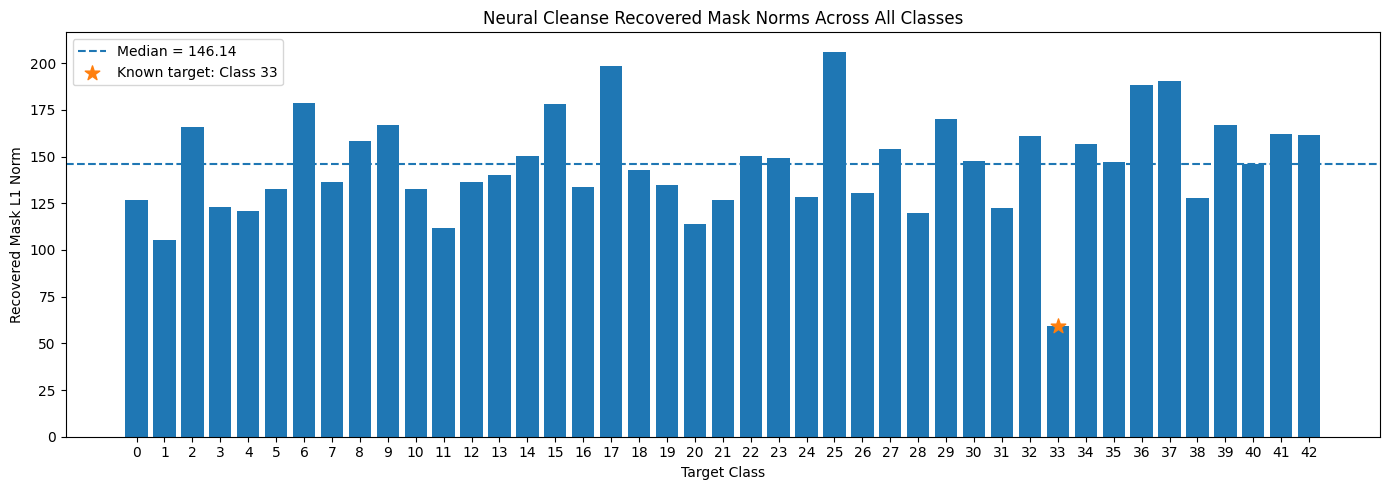

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.bar(
    range(NUM_CLASSES),
    mask_norms
)

plt.axhline(
    median_norm,
    linestyle="--",
    label=f"Median = {median_norm:.2f}"
)

plt.scatter(
    [33],
    [mask_norms[33]],
    s=120,
    marker="*",
    label="Known target: Class 33"
)

plt.xlabel("Target Class")
plt.ylabel("Recovered Mask L1 Norm")

plt.title(
    "Neural Cleanse Recovered Mask Norms "
    "Across All Classes"
)

plt.xticks(range(NUM_CLASSES))

plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS / "all_class_mask_norms.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

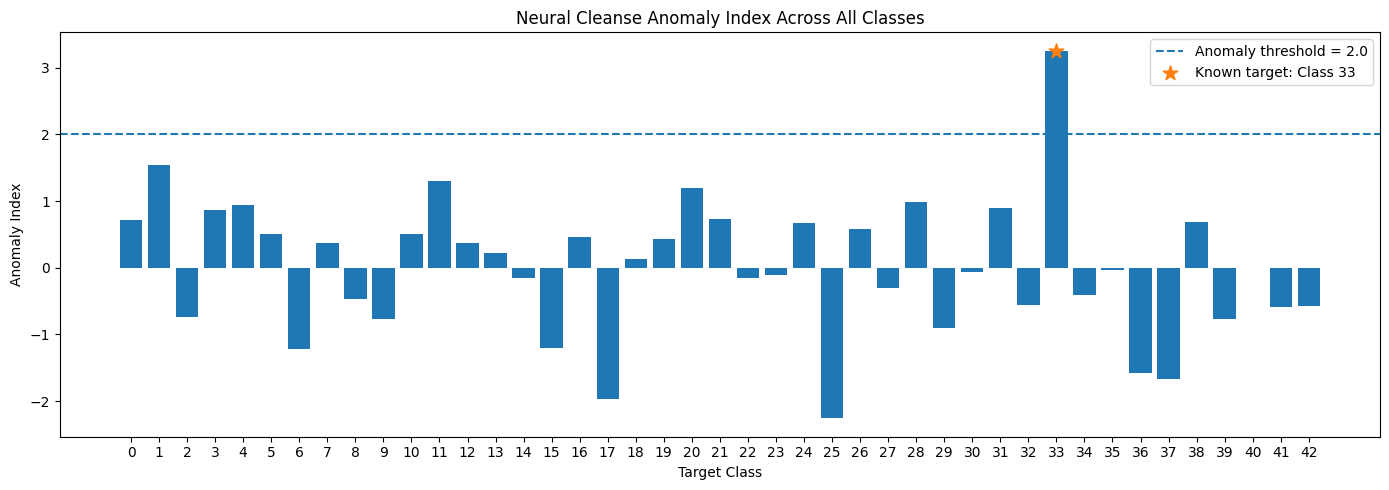

In [33]:
plt.figure(figsize=(14, 5))

plt.bar(
    range(NUM_CLASSES),
    anomaly_indices
)

plt.axhline(
    ANOMALY_THRESHOLD,
    linestyle="--",
    label="Anomaly threshold = 2.0"
)

plt.scatter(
    [33],
    [anomaly_indices[33]],
    s=120,
    marker="*",
    label="Known target: Class 33"
)

plt.xlabel("Target Class")
plt.ylabel("Anomaly Index")

plt.title(
    "Neural Cleanse Anomaly Index "
    "Across All Classes"
)

plt.xticks(range(NUM_CLASSES))

plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS / "anomaly_index.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

##Anomaly and Mask Comparison

After comparing the recovered masks across all 43 classes, class 33 produced the result that stood out in the anomaly-index calculation.

Median mask norm across the scan: 146.14
MAD: 17.95
Class 33 mask norm: 59.53
Class 33 anomaly index: 3.25
Suspicious threshold used in this experiment: 2.0
Class 33 was the class that exceeded the threshold. This is interesting because class 33 is also the known target of the provided backdoor, so the anomaly-index result lined up with what I expected to find.

The following visualizations help me compare the recovered mask sizes, anomaly indices, and mask appearances. The visual differences are useful for understanding the results, while the anomaly index provides a numerical way to identify which class stands out from the others.

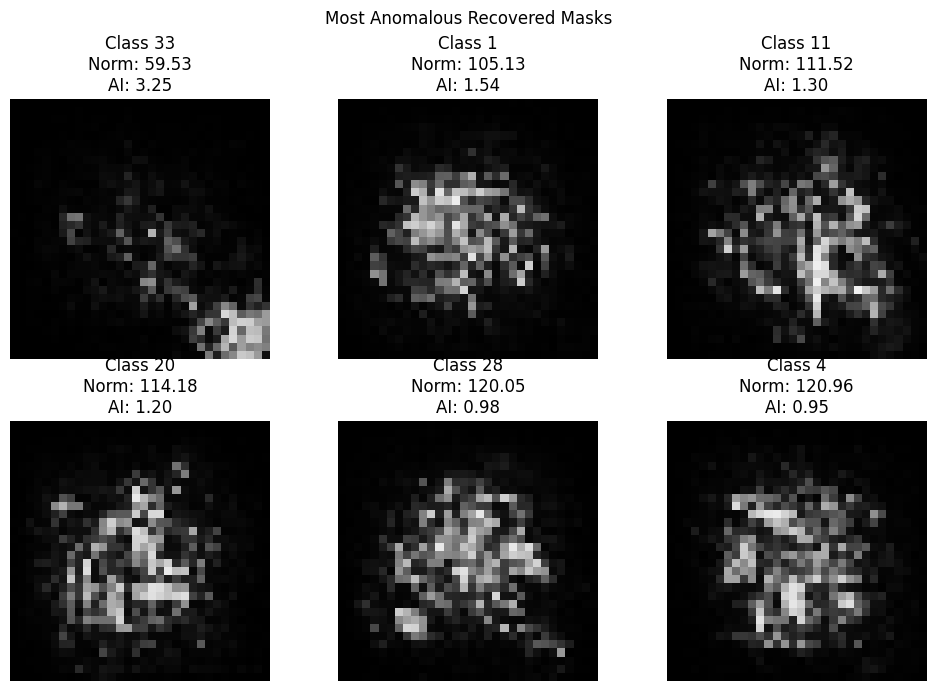

In [34]:
top_classes = ranking[:6]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 7)
)

axes = axes.flatten()

for ax, target in zip(
    axes,
    top_classes
):

    recovered_mask = scan_results[
        target
    ]["mask"]

    ax.imshow(
        recovered_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"Class {target}\n"
        f"Norm: {mask_norms[target]:.2f}\n"
        f"AI: {anomaly_indices[target]:.2f}"
    )

    ax.axis("off")

plt.suptitle(
    "Most Anomalous Recovered Masks"
)

plt.tight_layout()

plt.savefig(
    RESULTS / "top_anomalous_masks.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

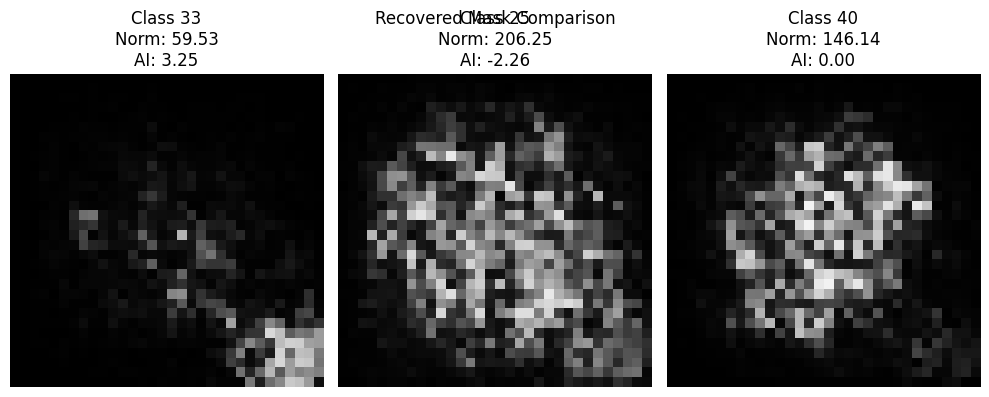

In [35]:
normal_candidates = [
    target
    for target in ranking[::-1]
    if target != 33
]

comparison_classes = [
    33,
    normal_candidates[0],
    normal_candidates[len(normal_candidates)//2]
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(10, 4)
)

for ax, target in zip(
    axes,
    comparison_classes
):

    ax.imshow(
        scan_results[target]["mask"],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"Class {target}\n"
        f"Norm: {mask_norms[target]:.2f}\n"
        f"AI: {anomaly_indices[target]:.2f}"
    )

    ax.axis("off")

plt.suptitle(
    "Recovered Mask Comparison"
)

plt.tight_layout()

plt.savefig(
    RESULTS / "mask_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Conclusion

In this experiment, I worked through both backdoor trigger recovery and anomaly-based backdoor detection using Neural Cleanse.

The provided backdoor produced a **97.6% attack success rate** toward class 33, while the trigger recovered through Neural Cleanse achieved a **91.4% attack success rate**. I then expanded the recovery process across all 43 target classes so that the recovered mask sizes could be compared.

During the all-class scan, class 33 produced a mask norm of **59.53** and an anomaly index of **3.25**, which was above the **2.0 threshold** used in this experiment. This lined up with class 33 being the known target of the provided backdoor.

The final mask comparisons helped me understand how the numerical anomaly index can be used together with the recovered mask visualizations to identify a class that stands out from the others.